# Modelo Avanzado — Fine-Tuning Transformer (BETO)

**Autor:** Sebastián Ruiz  
**Proyecto:** Aprendizaje Profundo · Maestría en IA · Pontificia Universidad Javeriana · 2026  
**Dataset:** Andalusian Hotels Reviews (5 clases, desbalanceado)

---

## Estrategia

1. **Fine-tuning** de BETO (`dccuchile/bert-base-spanish-wwm-cased`), un modelo BERT pre-entrenado en español.
2. **Congelamiento parcial**: solo se descongelan la última capa del encoder (`layer.11`), el pooler y el clasificador (~7% de parámetros).
3. **Class weights** balanceados para manejar el desbalance del dataset.
4. **Evaluación** con métricas estándar: accuracy, F1 macro, F1 por clase y matriz de confusión.

> **Nota:** Este notebook fue diseñado para ejecutarse en Google Colab con GPU.

## 1. Configuración y entorno

In [1]:
# ── 1a. Setup Colab ──────────────────────────────────────────────────────────
# NOTA: Esta celda solo aplica en Google Colab. En entorno local, ignorar
#       y asegurarse de estar en la carpeta notebooks/ del repositorio.

# import os
#
# REPO_URL = "https://github.com/JuanSe1796/Proyecto_Deep_Learning_Final.git"
# REPO_DIR = "/content/Proyecto_Deep_Learning_Final"
#
# if not os.path.exists(REPO_DIR):
#     os.system(f"git clone {REPO_URL} {REPO_DIR}")
#     print("Repositorio clonado.")
# else:
#     print("Repositorio ya existe — haciendo pull...")
#     os.system(f"git -C {REPO_DIR} pull")
#
# os.chdir(f"{REPO_DIR}/notebooks")
# print(f"Working directory: {os.getcwd()}")

import os
print(f"Working directory: {os.getcwd()}")

Working directory: C:\freyesp\Proyecto_Deep_Learning_Final\notebooks


In [2]:
# ── 1b. Configuración global ─────────────────────────────────────────────────
import torch
import numpy as np
import random
import os
from pathlib import Path

# SEMILLA FIJA = 42
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
elif torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

# DEVICE: compatible con CUDA (Colab/GPU), MPS (Mac M2) y CPU
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f'Semilla fija : {SEED}')
print(f'Dispositivo  : {DEVICE}')
print(f'PyTorch      : {torch.__version__}')

# PATHS
DATA_DIR    = Path('../data')
RESULTS_DIR = Path('../results')
FIGURES_DIR = Path('../figures')

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = RESULTS_DIR / 'transformer_best.pt'
print(f'DATA_DIR    : {DATA_DIR}')
print(f'RESULTS_DIR : {RESULTS_DIR}')
print(f'FIGURES_DIR : {FIGURES_DIR}')

Semilla fija : 42
Dispositivo  : cuda
PyTorch      : 2.12.0+cu132
DATA_DIR    : ..\data
RESULTS_DIR : ..\results
FIGURES_DIR : ..\figures


## 2. Instalación de dependencias

In [3]:
# ── 2. Instalación de dependencias ───────────────────────────────────────────
#!pip install -q transformers accelerate datasets scikit-learn seaborn
print("Dependencias instaladas.")

Dependencias instaladas.


## 3. Carga de los splits

In [4]:
# ── 3. Cargar splits ─────────────────────────────────────────────────────────
import pandas as pd

train_df = pd.read_csv(DATA_DIR / 'train.csv')
val_df   = pd.read_csv(DATA_DIR / 'val.csv')
test_df  = pd.read_csv(DATA_DIR / 'test.csv')

print(f'Train : {len(train_df):>5} muestras')
print(f'Val   : {len(val_df):>5} muestras')
print(f'Test  : {len(test_df):>5} muestras')
print(f'Total : {len(train_df)+len(val_df)+len(test_df):>5} muestras')
print('Distribución train:', train_df['label'].value_counts().sort_index().to_dict())

Train : 12720 muestras
Val   :  2726 muestras
Test  :  2726 muestras
Total : 18172 muestras
Distribución train: {0: 1174, 1: 696, 2: 1592, 3: 2955, 4: 6303}


## 4. Tokenización y DataLoaders

> **Optimización aplicada:** se pre-tokeniza todo el dataset una sola vez en `__init__` en lugar de tokenizar en cada `__getitem__`. Esto evita re-tokenizar las mismas muestras en cada época (con 5 épocas y ~18k muestras, se pasa de ~90k llamadas al tokenizador a solo ~18k), reduciendo significativamente el tiempo de entrenamiento.

In [5]:
# ── 4a. Tokenizador BETO ─────────────────────────────────────────────────────
from transformers import AutoTokenizer

MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Verificación con un ejemplo real del split de entrenamiento
ejemplo = train_df['review_text'].iloc[0]
tokens  = tokenizer(ejemplo, truncation=True, max_length=128, padding='max_length')

print(f"Modelo        : {MODEL_NAME}")
print(f"Vocab size    : {tokenizer.vocab_size}")
print(f"Input IDs     : {tokens['input_ids'][:10]} ...")
print(f"Attention mask: {tokens['attention_mask'][:10]} ...")

Modelo        : dccuchile/bert-base-spanish-wwm-cased
Vocab size    : 31002
Input IDs     : [4, 1177, 1049, 5225, 1311, 6794, 1042, 16232, 1017, 1108] ...
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1] ...


In [6]:
# ── 4b. Dataset y DataLoaders (pre-tokenizado) ──────────────────────────────
from torch.utils.data import Dataset, DataLoader

MAX_LEN    = 128
BATCH_SIZE = 32

class HotelReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.labels = torch.tensor(labels.values, dtype=torch.long)
        # Pre-tokenizar todo el dataset de una vez (mucho más eficiente)
        encoded = tokenizer(
            texts.tolist(),
            truncation=True,
            max_length=max_len,
            padding='max_length',
            return_tensors='pt'
        )
        self.input_ids      = encoded['input_ids']
        self.attention_mask = encoded['attention_mask']
        print(f"  Pre-tokenizadas {len(self.labels):,} muestras")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids'     : self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'label'         : self.labels[idx]
        }

# Crear datasets (la tokenización ocurre aquí, una sola vez)
print("Pre-tokenizando datasets...")
train_dataset = HotelReviewDataset(train_df['review_text'], train_df['label'], tokenizer, MAX_LEN)
val_dataset   = HotelReviewDataset(val_df['review_text'],   val_df['label'],   tokenizer, MAX_LEN)
test_dataset  = HotelReviewDataset(test_df['review_text'],  test_df['label'],  tokenizer, MAX_LEN)

# Crear DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"\nMAX_LEN       : {MAX_LEN}")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Batches train : {len(train_loader)}")
print(f"Batches val   : {len(val_loader)}")
print(f"Batches test  : {len(test_loader)}")

Pre-tokenizando datasets...
  Pre-tokenizadas 12,720 muestras
  Pre-tokenizadas 2,726 muestras
  Pre-tokenizadas 2,726 muestras

MAX_LEN       : 128
Batch size    : 32
Batches train : 398
Batches val   : 86
Batches test  : 86


## 5. Arquitectura del modelo

Fine-tuning de BETO: se congela todo el modelo excepto la última capa del encoder (`layer.11`), el pooler y el clasificador. Esto permite entrenar solo ~7% de los parámetros totales.

In [7]:
# ── 5. Arquitectura del modelo ────────────────────────────────────────────────
from transformers import AutoModelForSequenceClassification

NUM_CLASSES = 5

# Cargar BETO para clasificación
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
)

# Fine-Tuning: congelar todo excepto el último bloque del encoder + clasificador
# BETO tiene 12 capas (encoder.layer.0 ... encoder.layer.11)
# Congelamos todas menos la última (layer.11)

for name, param in model.named_parameters():
    param.requires_grad = False  # Congelar todo primero

for name, param in model.named_parameters():
    if any(layer in name for layer in ['encoder.layer.11', 'pooler', 'classifier']):
        param.requires_grad = True  # Descongelar última capa + clasificador

# Verificar qué quedó descongelado
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Parámetros totales     : {total_params:,}")
print(f"Parámetros entrenables : {trainable_params:,}")
print(f"Porcentaje entrenable  : {100*trainable_params/total_params:.1f}%")
print("\nCapas descongeladas:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  ✓ {name}")

model = model.to(DEVICE)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Parámetros totales     : 109,854,725
Parámetros entrenables : 7,682,309
Porcentaje entrenable  : 7.0%

Capas descongeladas:
  ✓ bert.encoder.layer.11.attention.self.query.weight
  ✓ bert.encoder.layer.11.attention.self.query.bias
  ✓ bert.encoder.layer.11.attention.self.key.weight
  ✓ bert.encoder.layer.11.attention.self.key.bias
  ✓ bert.encoder.layer.11.attention.self.value.weight
  ✓ bert.encoder.layer.11.attention.self.value.bias
  ✓ bert.encoder.layer.11.attention.output.dense.weight
  ✓ bert.encoder.layer.11.attention.output.dense.bias
  ✓ bert.encoder.layer.11.attention.output.LayerNorm.weight
  ✓ bert.encoder.layer.11.attention.output.LayerNorm.bias
  ✓ bert.encoder.layer.11.intermediate.dense.weight
  ✓ bert.encoder.layer.11.intermediate.dense.bias
  ✓ bert.encoder.layer.11.output.dense.weight
  ✓ bert.encoder.layer.11.output.dense.bias
  ✓ bert.encoder.layer.11.output.LayerNorm.weight
  ✓ bert.encoder.layer.11.output.LayerNorm.bias
  ✓ bert.pooler.dense.weight
  ✓ bert.pooler

## 6. Configuración de entrenamiento

- **Optimizer:** AdamW, lr=2e-5, weight_decay=0.01
- **Class weights:** balanceados (dataset desbalanceado)
- **Scheduler:** warmup lineal (10% de steps)
- **Gradient clipping:** 1.0
- **Early stopping:** paciencia 3 épocas sobre val_loss (restaura el mejor checkpoint al detenerse)

In [8]:
# ── 6. Configuración de entrenamiento ────────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight
from transformers import get_linear_schedule_with_warmup

# Class weights para manejar el desbalance
classes           = np.array([0, 1, 2, 3, 4])
class_weights     = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['label'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print("Class weights:")
for i, w in enumerate(class_weights):
    print(f"  Clase {i+1} (rating {i+1}★): {w:.4f}")

# Función de pérdida con class weights
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizador — torch.optim.AdamW
LR        = 2e-5
N_EPOCHS  = 15       # Máximo de épocas (early stopping corta antes si no mejora)
PATIENCE  = 3        # Épocas sin mejora en val_loss antes de detener

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=0.01
)

# Scheduler con warmup
total_steps  = len(train_loader) * N_EPOCHS
warmup_steps = total_steps // 10

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"\nLearning rate  : {LR}")
print(f"Épocas máximas : {N_EPOCHS}")
print(f"Early stopping : paciencia {PATIENCE}")
print(f"Total steps    : {total_steps}")
print(f"Warmup steps   : {warmup_steps}")

Class weights:
  Clase 1 (rating 1★): 2.1670
  Clase 2 (rating 2★): 3.6552
  Clase 3 (rating 3★): 1.5980
  Clase 4 (rating 4★): 0.8609
  Clase 5 (rating 5★): 0.4036

Learning rate  : 2e-05
Épocas máximas : 15
Early stopping : paciencia 3
Total steps    : 5970
Warmup steps   : 597


## 7. Entrenamiento

Early stopping con paciencia de 3 épocas: si `val_loss` no mejora durante 3 épocas consecutivas,
se detiene el entrenamiento y se restaura el mejor checkpoint guardado.

In [9]:
# ── 7. Entrenamiento ─────────────────────────────────────────────────────────
import time
from tqdm import tqdm


def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in tqdm(loader, desc="  Train", leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = criterion(outputs.logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="  Val  ", leave=False):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss    = criterion(outputs.logits, labels)

            total_loss += loss.item()
            preds       = outputs.logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total


# ── Historial para las curvas ──────────────────────────────────────────────
loss_history     = []
val_loss_history = []
acc_history      = []
val_acc_history  = []
best_val_loss    = float('inf')
best_epoch       = 1
patience_counter = 0
start_time       = time.time()

print(f"{'Época':>6} {'Train Loss':>11} {'Val Loss':>10} {'Train Acc':>10} {'Val Acc':>9} {'':>3}")
print("─" * 58)

for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, DEVICE)
    val_loss,   val_acc   = eval_epoch(model, val_loader, criterion, DEVICE)

    loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    # Checkpoint + Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch    = epoch
        patience_counter = 0
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"{epoch:>6} {train_loss:>11.4f} {val_loss:>10.4f} {train_acc:>10.4f} {val_acc:>9.4f}  ✓ Checkpoint guardado")
    else:
        patience_counter += 1
        print(f"{epoch:>6} {train_loss:>11.4f} {val_loss:>10.4f} {train_acc:>10.4f} {val_acc:>9.4f}    Early stopping: {patience_counter}/{PATIENCE}")

        if patience_counter >= PATIENCE:
            print(f"\n  Early stopping activado en época {epoch}.")
            print(f"  Restaurando mejor checkpoint (época {best_epoch}, val_loss={best_val_loss:.4f})...")
            model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=True))
            break

elapsed = time.time() - start_time
epochs_run = len(loss_history)
print(f"\n  Entrenamiento completado en {elapsed:.0f}s | Épocas: {epochs_run}/{N_EPOCHS} | Mejor época: {best_epoch}")
print(f"  Checkpoint: {CHECKPOINT_PATH}")

 Época  Train Loss   Val Loss  Train Acc   Val Acc    
──────────────────────────────────────────────────────────


     1      1.4603     1.1921     0.4093    0.5745  ✓ Checkpoint guardado


     2      1.0365     0.9901     0.6013    0.6284  ✓ Checkpoint guardado


     3      0.9238     0.9443     0.6432    0.6511  ✓ Checkpoint guardado


     4      0.8808     0.9092     0.6503    0.6662  ✓ Checkpoint guardado


     5      0.8385     0.9173     0.6692    0.6676    Early stopping: 1/3


     6      0.8088     0.9115     0.6803    0.6768    Early stopping: 2/3


     7      0.7716     0.9255     0.6892    0.6713    Early stopping: 3/3

  Early stopping activado en época 7.
  Restaurando mejor checkpoint (época 4, val_loss=0.9092)...

  Entrenamiento completado en 1024s | Épocas: 7/15 | Mejor época: 4
  Checkpoint: ..\results\transformer_best.pt


## 8. Evaluación en test set

Una sola evaluación sobre el test set (nunca se usó para ajustar hiperparámetros).

In [10]:
# ── 8. Evaluación en test set ────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score, confusion_matrix

def evaluate_model(model, loader, checkpoint_path, device):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="  Test"):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = outputs.logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

y_true, y_pred = evaluate_model(model, test_loader, CHECKPOINT_PATH, DEVICE)

# Calcular métricas
accuracy                    = accuracy_score(y_true, y_pred)
precision, recall, f1, _    = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
f1_per_class_arr            = f1_score(y_true, y_pred, average=None, zero_division=0)
cm                          = confusion_matrix(y_true, y_pred).tolist()

CLASS_NAMES  = ["1", "2", "3", "4", "5"]
f1_per_class = {CLASS_NAMES[i]: round(float(v), 6) for i, v in enumerate(f1_per_class_arr)}

print("── Métricas finales (test set) ─────────────────────────")
print(f"  Accuracy        : {accuracy:.4f}")
print(f"  Precision macro : {precision:.4f}")
print(f"  Recall macro    : {recall:.4f}")
print(f"  F1 macro        : {f1:.4f}")
print("  F1 por clase:")
for cls, val in f1_per_class.items():
    print(f"    Clase {cls}★ : {val:.4f}")
print("────────────────────────────────────────────────────────")

  Test: 100%|██████████████████████████████████████████████████████████████████████████| 86/86 [00:22<00:00,  3.84it/s]

── Métricas finales (test set) ─────────────────────────
  Accuracy        : 0.6706
  Precision macro : 0.5837
  Recall macro    : 0.6106
  F1 macro        : 0.5926
  F1 por clase:
    Clase 1★ : 0.7109
    Clase 2★ : 0.4188
    Clase 3★ : 0.5128
    Clase 4★ : 0.5065
    Clase 5★ : 0.8141
────────────────────────────────────────────────────────


## 9. Guardar métricas

In [11]:
# ── 9. Guardar métricas en JSON ──────────────────────────────────────────────
import json

metrics_dict = {
    "model_name": "beto_finetuned",
    "owner": "Sebastián Ruiz",
    "track": "TI",
    "config": {
        "base_model": MODEL_NAME,
        "layers_unfrozen": ["encoder.layer.11", "pooler", "classifier"],
        "max_len": MAX_LEN,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "weight_decay": 0.01,
        "use_class_weights": True,
        "early_stopping_patience": PATIENCE,
        "n_params": sum(p.numel() for p in model.parameters()),
        "trainable_params": sum(p.numel() for p in model.parameters() if p.requires_grad)
    },
    "metrics": {
        "accuracy":         round(float(accuracy), 6),
        "precision_macro":  round(float(precision), 6),
        "recall_macro":     round(float(recall), 6),
        "f1_macro":         round(float(f1), 6),
        "f1_per_class":     f1_per_class,
        "confusion_matrix": cm
    },
    "training": {
        "epochs_max":        N_EPOCHS,
        "epochs_run":        len(loss_history),
        "best_epoch":        best_epoch,
        "training_time_seconds": int(elapsed),
        "loss_history":      loss_history,
        "val_loss_history":  val_loss_history,
        "acc_history":       acc_history,
        "val_acc_history":   val_acc_history
    }
}

json_path = RESULTS_DIR / "transformer_metrics.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, indent=2, ensure_ascii=False)

print(f"JSON guardado → {json_path}")

JSON guardado → ..\results\transformer_metrics.json


## 10. Visualizaciones

Curvas de entrenamiento (loss y accuracy) y matrices de confusión (normalizada y absoluta).

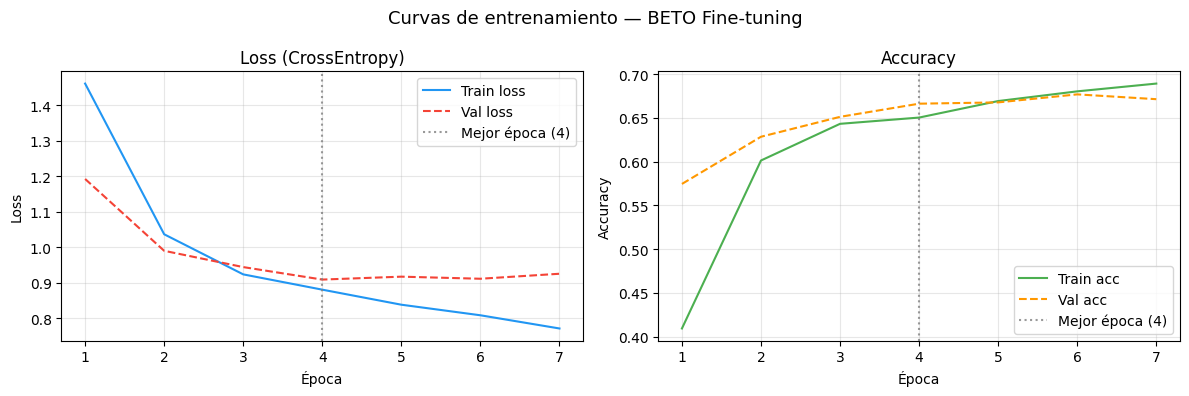

Guardado → ..\figures\transformer_curves.png


In [12]:
# ── 10a. Curvas de entrenamiento ─────────────────────────────────────────────
import matplotlib.pyplot as plt

epochs = range(1, len(loss_history) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Curvas de entrenamiento — BETO Fine-tuning", fontsize=13)

# Loss
ax = axes[0]
ax.plot(epochs, loss_history,     label="Train loss", color="#2196F3")
ax.plot(epochs, val_loss_history, label="Val loss",   color="#F44336", linestyle="--")
ax.axvline(best_epoch, color="gray", linestyle=":", alpha=0.8, label=f"Mejor época ({best_epoch})")
ax.set_xlabel("Época"); ax.set_ylabel("Loss")
ax.set_title("Loss (CrossEntropy)"); ax.legend(); ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[1]
ax.plot(epochs, acc_history,     label="Train acc", color="#4CAF50")
ax.plot(epochs, val_acc_history, label="Val acc",   color="#FF9800", linestyle="--")
ax.axvline(best_epoch, color="gray", linestyle=":", alpha=0.8, label=f"Mejor época ({best_epoch})")
ax.set_xlabel("Época"); ax.set_ylabel("Accuracy")
ax.set_title("Accuracy"); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
curves_path = FIGURES_DIR / "transformer_curves.png"
plt.savefig(curves_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado → {curves_path}")

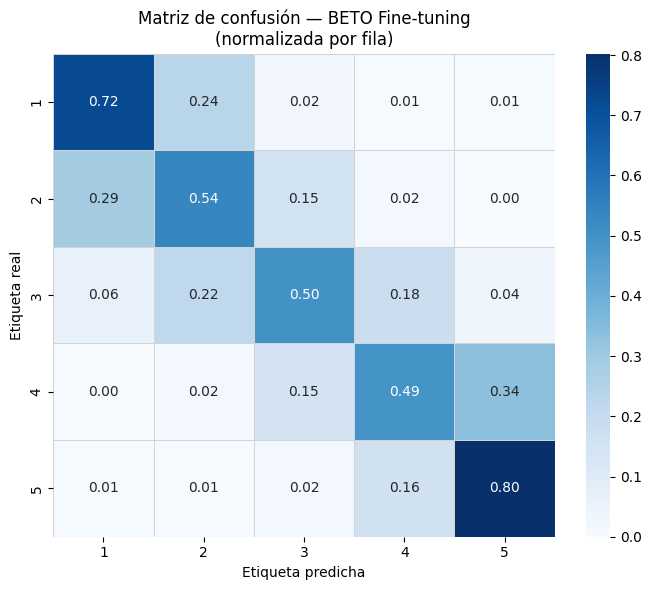

Guardado → ..\figures\transformer_confusion.png


In [13]:
# ── 10b. Matriz de confusión (normalizada) ───────────────────────────────────
import seaborn as sns

cm_array = np.array(cm)
cm_norm  = cm_array / cm_array.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax, linewidths=0.5, linecolor="lightgray"
)
ax.set_title("Matriz de confusión — BETO Fine-tuning\n(normalizada por fila)", fontsize=12)
ax.set_ylabel("Etiqueta real")
ax.set_xlabel("Etiqueta predicha")
plt.tight_layout()

cm_path = FIGURES_DIR / "transformer_confusion.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado → {cm_path}")

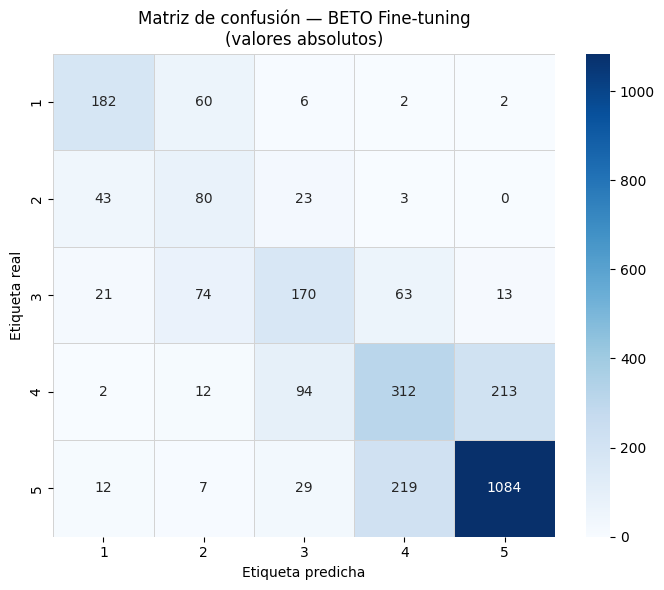

Guardado → ..\figures\transformer_confusion_absolutos.png


In [14]:
# ── 10c. Matriz de confusión (valores absolutos) ────────────────────────────
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

cm_array = np.array(cm)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_array, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax, linewidths=0.5, linecolor="lightgray"
)
ax.set_title("Matriz de confusión — BETO Fine-tuning\n(valores absolutos)", fontsize=12)
ax.set_ylabel("Etiqueta real")
ax.set_xlabel("Etiqueta predicha")
plt.tight_layout()

cm_path = FIGURES_DIR / "transformer_confusion_absolutos.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado → {cm_path}")

## 11. Descarga de archivos

In [15]:
# ── 11. Descarga de archivos (solo Colab) ────────────────────────────────────
# NOTA: google.colab solo existe en Google Colab. En entorno local, los
#       archivos ya están guardados en results/ y figures/.

# from google.colab import files
#
# archivos = [
#     "../results/transformer_metrics.json",
#     "../figures/transformer_curves.png",
#     "../figures/transformer_confusion.png",
# ]
#
# for path in archivos:
#     if os.path.exists(path):
#         files.download(path)
#         print(f"Descargando: {path}")
#     else:
#         print(f"FALTA: {path}")

import os
print("Archivos generados:")
for d in ["../results", "../figures"]:
    if os.path.exists(d):
        for f in sorted(os.listdir(d)):
            if "transformer" in f:
                print(f"  {d}/{f}")

Archivos generados:
  ../results/transformer_best.pt
  ../results/transformer_metrics.json
  ../figures/transformer_confusion.png
  ../figures/transformer_confusion_absolutos.png
  ../figures/transformer_curves.png
